<a href="https://colab.research.google.com/github/alexmordashov/image_processing/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%961b_%D0%A4%D0%B8%D0%BB%D1%8C%D1%82%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9_%D1%81_%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%D0%BC_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BA%D0%B8_%D0%B2_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [40]:
dirname_ = os.path.abspath('IMAGES')
image_names = ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']
for file_ in os.listdir(dirname_):
  os.rename(f'{dirname_}/{file_}', f'{dirname_}/{file_.split(".")[0]}.jpg')

for file_ in image_names:
  filename = f'{dirname_}/{file_}'
  #image = cv2.imdecode(np.fromfile(filename, dtype=np.uint8), cv2.IMREAD_COLOR)
  image = cv2.imread(filename)

  # Применяем фильтр низких частот
  kernel_low = np.array([[1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1],
                     [1, 1, 1, 1, 1]])
  kernel_low = kernel_low / (np.sum(kernel_low) if np.sum(kernel_low) != 0 else 1)
  image_low = cv2.filter2D(image, -1, kernel_low)
  cv2.imwrite(f'{dirname_}/{file_.split(".")[0]}_low_filter.jpg', image_low)

  # Применяем фильтры высоких частот
  kernel_high_1 = np.array([[0, -1, 0],
                            [-1, 4, -1],
                            [0, -1, 0]])
  kernel_high_1 = kernel_high_1 / (np.sum(kernel_high_1) if np.sum(kernel_high_1) != 0 else 1)
  image_high_1 = cv2.filter2D(image, -1, kernel_high_1)
  cv2.imwrite(f'{dirname_}/{file_.split(".")[0]}_high_filter_1.jpg', image_high_1)

  kernel_high_2 = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]])
  kernel_high_2 = kernel_high_2 / (np.sum(kernel_high_2) if np.sum(kernel_high_2) != 0 else 1)
  image_high_2 = cv2.filter2D(image, -1, kernel_high_2)
  cv2.imwrite(f'{dirname_}/{file_.split(".")[0]}_high_filter_2.jpg', image_high_2)

  kernel_high_3 = np.array([[-1, 0, 1],
                            [-2, 0, 2],
                            [-1, 0, 1]])
  kernel_high_3 = kernel_high_3 / (np.sum(kernel_high_3) if np.sum(kernel_high_3) != 0 else 1)
  image_high_3 = cv2.filter2D(image, -1, kernel_high_3)
  cv2.imwrite(f'{dirname_}/{file_.split(".")[0]}_high_filter_3.jpg', image_high_3)

  kernel_high_4 = np.array([[-1, -2, -1],
                            [0, 0, 0],
                            [1, 2, 1]])
  kernel_high_4 = kernel_high_4 / (np.sum(kernel_high_4) if np.sum(kernel_high_4) != 0 else 1)
  image_high_4 = cv2.filter2D(image, -1, kernel_high_4)
  cv2.imwrite(f'{dirname_}/{file_.split(".")[0]}_high_filter_4.jpg', image_high_4)

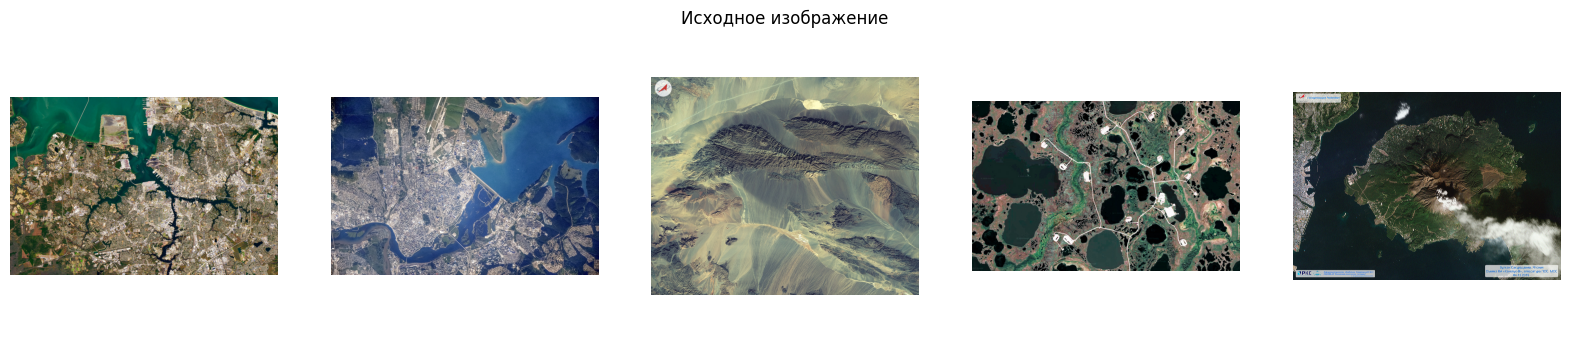

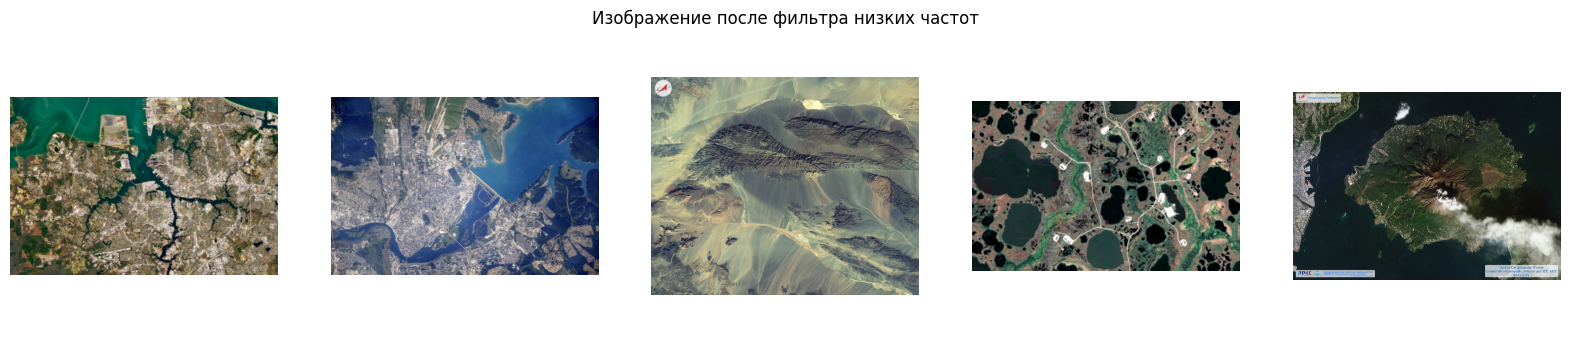

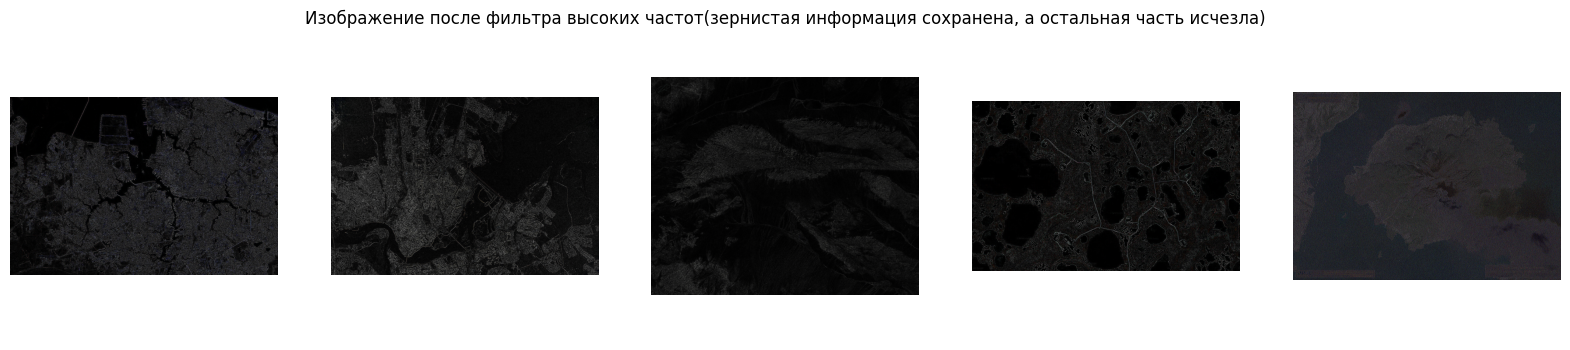

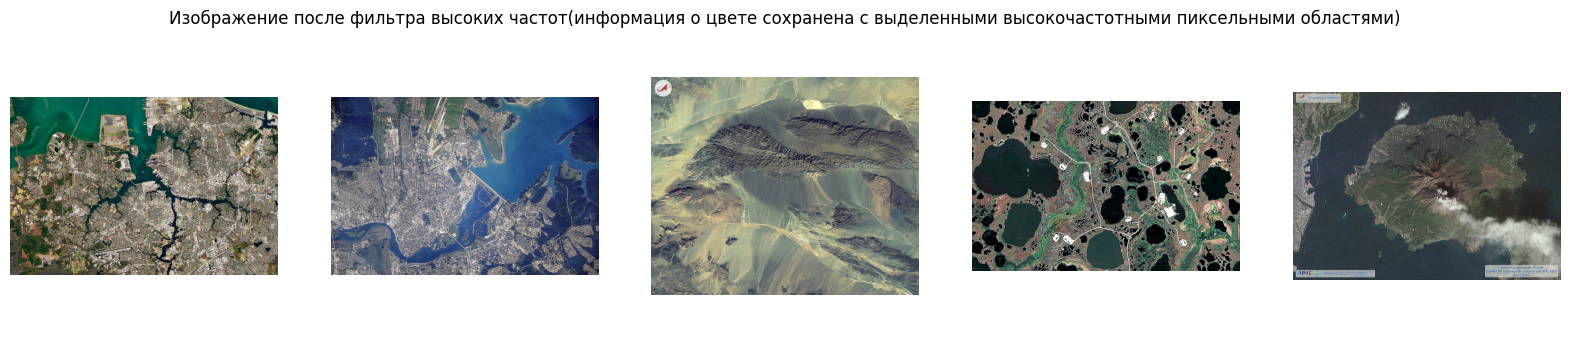

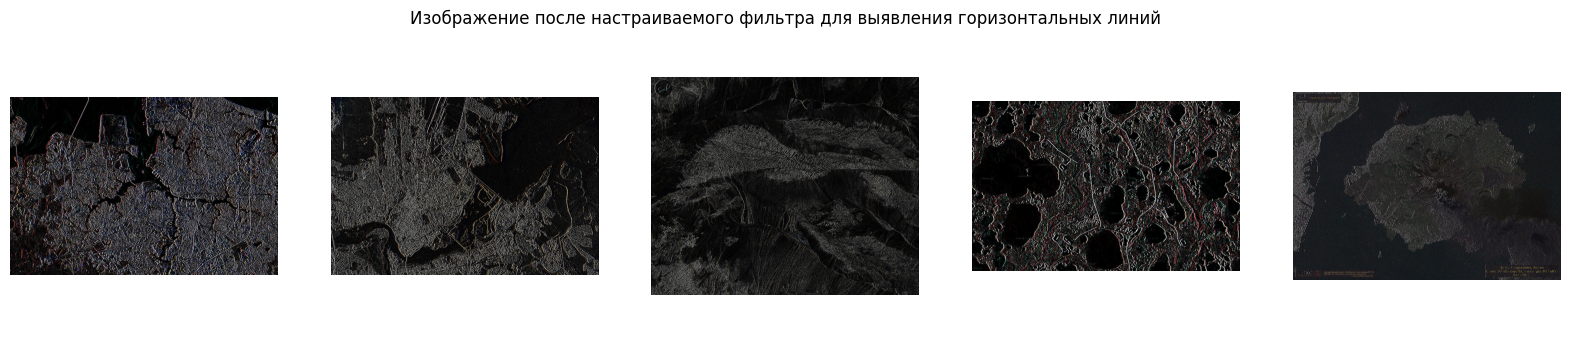

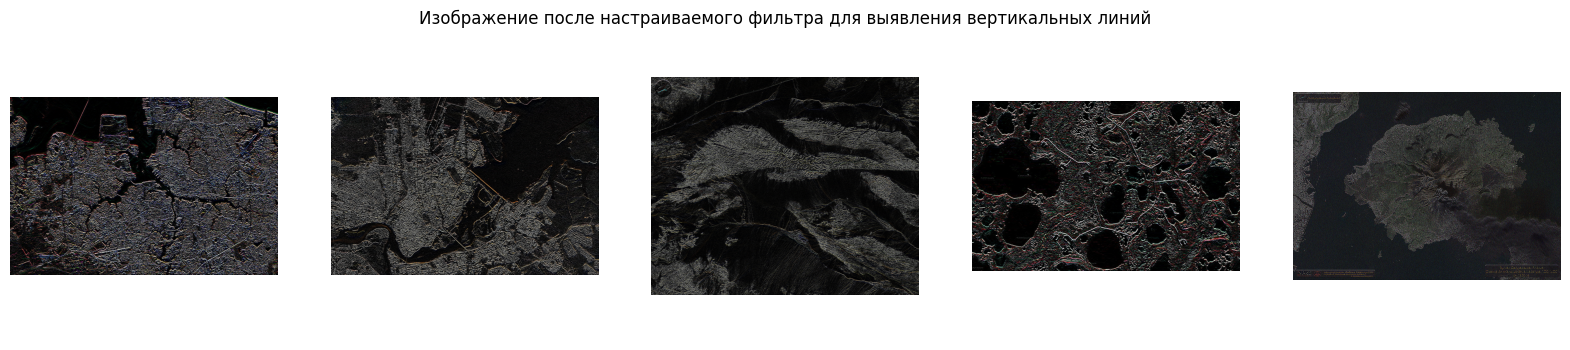

In [44]:
filters = ['.jpg', '_low_filter.jpg', '_high_filter_1.jpg', '_high_filter_2.jpg', '_high_filter_3.jpg', '_high_filter_4.jpg']
title_names = [
    'Исходное изображение',
    'Изображение после фильтра низких частот',
    'Изображение после фильтра высоких частот(зернистая информация сохранена, а остальная часть исчезла)',
    'Изображение после фильтра высоких частот(информация о цвете сохранена с выделенными высокочастотными пиксельными областями)',
    'Изображение после настраиваемого фильтра для выявления горизонтальных линий',
    'Изображение после настраиваемого фильтра для выявления вертикальных линий'
]
for filter_name in filters:
  plt.figure(figsize=(20, 4))

  plt.title(title_names[filters.index(filter_name)])
  plt.axis('off')
  for i in range(len(image_names)):
    image_file = cv2.imread(f'{dirname_}/{i + 1}{filter_name}')
    plt.subplot(1, len(image_names), i + 1)
    plt.imshow(cv2.cvtColor(image_file, cv2.COLOR_BGR2RGB))
    plt.axis('off')
  plt.show()

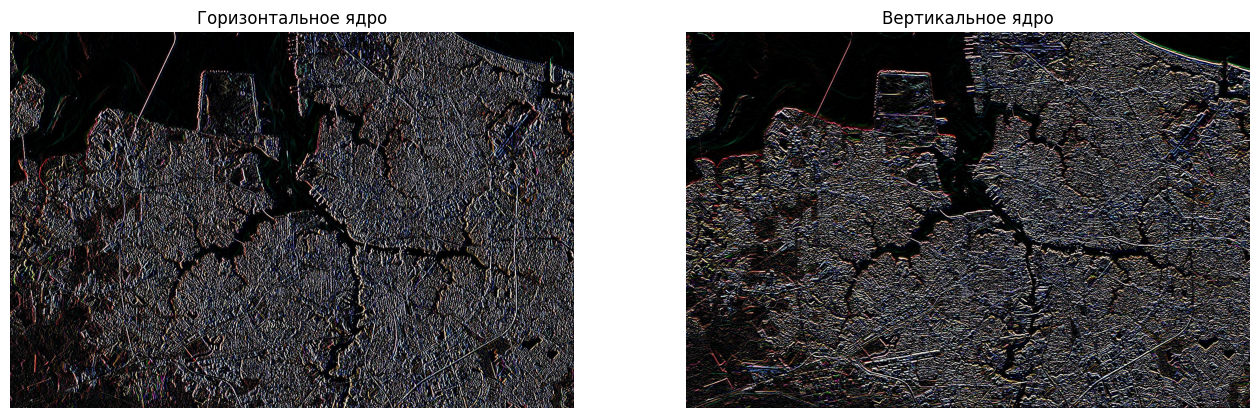

In [42]:
horizontal_image = cv2.imread(f'{dirname_}/1_high_filter_3.jpg')
vertical_image = cv2.imread(f'{dirname_}/1_high_filter_4.jpg')

plt.figure(figsize=(16, 12))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(horizontal_image, cv2.COLOR_BGR2RGB))
plt.title('Горизонтальное ядро')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(vertical_image, cv2.COLOR_BGR2RGB))
plt.title('Вертикальное ядро')
plt.axis('off')

plt.show()